Luc, Pasal<br>
2. November 2025

# Summary

For Module 2 in CAS Digital Life Sience I want to improve my workouts (strength training) with the help of the data (Heart Rate, SPO2, Weight / multivariate aperiodic timeseries) from my health app and probably additional training notes in a time series, over a month.

As the targeted health app "Huawei health" has no individuallized monitoring for the my exercises, and neither a function during the training to suggest improvements, except in which heart rate zone I currently am, it is worth to further analyzed the logged data for the following insights:

Do I take breaks seriously -> If intensity is too high, systemic fatique will lower the quality of the rest of the session
or am I distracted (talking to people / writing / strolling around ). -> lost focus and time in training

Do I execute the exercise properly? 
It is required to do each exercise in the specific rythm. -> If I do them to fast, the quality of the exercise is lost, if I do them to slow, I exert unnecessary effort in other bodyparts, or might add additional weights for progress.

And other questions like:
Does my resting heart rate and weight improve over time?  
Using the Metabolic EquivalenT I can calculate the calories burned during the day.

The last question might require ML:
Is it possible train a model to recognise the distinct exercise using only the raw data from the health app,
after a period of using the additional training notes in the beginning?

Open Question:
Will the model be transferable to another individual? Since I as a individual person have specific body composition and conditions.

Challenges:
Recurring exercises every week, for comparability.
Wearables 7 days a week (5 Workout days / 2 recovery days at the weekend)
Interpolation and mapping of manual notes to the raw data: Time taken, Type of Exercise, Weight used for each exercise, Reps and sets.
(solved) Data is exportable from the health app, the following is tested: Watch -> Health app on android -> Google Drive -> Download TCX Files (XML-Standard)

Alternative: OpenGov data


# Imports

TODO: if you are using libraries that were not introduced during the course, explain in a comment what you are using the library for.

<font color='orange'>WARNING</font>: not all Python libraries are safe to use. Make sure you do your due diligence before installing libraries you find on in the internet. The following article gives some good advice on how to assess a Python package: https://realpython.com/python-package-quality/



In [6]:
import xml.etree.ElementTree as ET
import pandas as pd
from datetime import *
import os 
import shutil
import pandas as pd
import numpy as np
from scipy import stats
import skchange 
import functools
from time import time
import seaborn as sns
import matplotlib.pyplot as plt
from PIL import Image
import requests
from io import BytesIO
import plotly.graph_objects as go
import re
from scipy.signal import find_peaks as fp

# Constants
global WORKING_DIRECTORY, RAW_DATAFILES, MERGEDDATAFILES, HOMOGENIZEDDATAFILES, SUPPORTED_FILEFORMATS, LOG_CALL, ADD_TCX,LastTCXFile

# Get the current working directory
cwd = os.getcwd()
WORKING_DIRECTORY = os.path.dirname(cwd) #Parent directory

print("The current working directory is:", WORKING_DIRECTORY)

DATA_DIRECTORY = WORKING_DIRECTORY + "\\data"

# Set subdirectories
Activity_Directory = DATA_DIRECTORY+ "\\Health Sync Activities\\"
Summary_Directory = DATA_DIRECTORY+ "\\Health Sync Summary\\"
HR_DIRECTORY = DATA_DIRECTORY+ "\\Health Sync Heart rate\\"
Steps_DIRECTORY = DATA_DIRECTORY+ "\\Health Sync Steps\\"
Weight_DIRECTORY = DATA_DIRECTORY+ "\\Health Sync Weight\\"
Exercise_DIRECTORY = DATA_DIRECTORY+ "\\Manual Exercise\\"

AllSourceFolders=[Activity_Directory,Summary_Directory,HR_DIRECTORY,Steps_DIRECTORY,Weight_DIRECTORY,Exercise_DIRECTORY]


#Raw Data Files {key=filename,value=pd.dataframe}
RAWDATAFILES={}
MERGEDDATAFILES={}
HOMOGENIZEDDATAFILES={}

LastTCXFile=""

#Log function calls (boolean)
LOG_CALL=False

#Garmin xml definitions for TCX files
GARMIN_XML_SCHEMA = '{http://www.garmin.com/xmlschemas/TrainingCenterDatabase/v2}'
GARMIN_XML_EXTENSIONS = '{http://www.garmin.com/xmlschemas/ActivityExtension/v2}'

#Additional TCX Infos
ADD_TCX={}


The current working directory is: h:\Documents\My Training\CAS\CAS_DLS\0_Module\M2_Data_Analysis_Foundation


# Data acquisition

For this project, try to avoid "preparing" your data in Excel. Instead, write Python code to work with "impecfect" data files.

In [7]:
#refurbished from 1. module
def loadfile(filename):
    """
    Arguments
    filename: must be full unc path
    """
    try:
        global RAWDATAFILES
        parent_folder= os.path.abspath(os.path.join(filename, os.pardir)).split("\\")[-1]
        base_name = os.path.basename(filename)

        #Choose respective reader according to filetype
        df=SUPPORTED_FILEFORMATS[filename.upper().split(".")[-1]](filename)
        #df.info()        
        #Append the data frame to the global dictionary for further usage
        RAWDATAFILES[parent_folder + ":" + base_name] = df.copy()
        print(f"File {base_name} successfully loaded.")
        
    except Exception as e:  
        print(f"Could not load file: {filename}. Error: {e}") 

# Function to read the TCX file using standard XML library
def TCX2DF(file_location):
    """
    Arguments
    filename: must be full unc path
    """
    tree = ET.parse(file_location)
    root = tree.getroot()
    df=[]
    timelist=[]
    hrlist=[]

    
    for node in root:
        if node.tag == GARMIN_XML_SCHEMA + 'Activities':
            for activity in node:
                if activity.tag == GARMIN_XML_SCHEMA + 'Activity':
                    # Sport Type
                    #print("Activity: " +activity.attrib['Sport'])
                    # Parse <Lap> elements inside an Activity
                    for lap_node in activity:
                        if lap_node.tag == GARMIN_XML_SCHEMA + 'Lap':
                            #print(lap_node.attrib['StartTime'])
                            StartTime =lap_node.attrib['StartTime']
                            for lap_child in lap_node:
                                    # Calories
                                    if lap_child.tag == GARMIN_XML_SCHEMA + 'Calories':
                                        calories = int(round(float(lap_child.text)))
                                        #print(f"calories:{ calories }")
                                    elif lap_child.tag == GARMIN_XML_SCHEMA + 'TotalTimeSeconds':
                                        TotalTimeSeconds = int(round(float(lap_child.text)))                                   
                                        #print(f"TotalTimeSeconds:{ TotalTimeSeconds }")
                                    elif lap_child.tag == GARMIN_XML_SCHEMA + 'Intensity':
                                        Intensity = lap_child.text
                                        #print(f"Intensity:{ Intensity }")
                                    elif lap_child.tag == GARMIN_XML_SCHEMA + 'TriggerMethod':
                                        TriggerMethod = lap_child.text
                                        #print(f"TriggerMethod:{ TriggerMethod }")
                                    elif lap_child.tag == GARMIN_XML_SCHEMA + 'TotalTimeSeconds':
                                        TotalTimeSeconds = int(round(float(lap_child.text)))                                   
                                        #print(f"TotalTimeSeconds:{ TotalTimeSeconds }")
                                    elif lap_child.tag == GARMIN_XML_SCHEMA + 'AverageHeartRateBpm':
                                        for el in lap_child:
                                            AverageHeartRateBpm=el.text
                                            #print(f"AverageHeartRateBpm:{ AverageHeartRateBpm }")
                                    elif lap_child.tag == GARMIN_XML_SCHEMA + 'MaximumHeartRateBpm':
                                        for el in lap_child:
                                            MaximumHeartRateBpm=el.text
                                            #print(f"MaximumHeartRateBpm:{ MaximumHeartRateBpm }")
                                    # Track (set of Trackpoint)
                                    elif lap_child.tag == GARMIN_XML_SCHEMA + 'Track':
                                        for trackpoint in lap_child:
                                            if trackpoint.tag == GARMIN_XML_SCHEMA + 'Trackpoint':
                                                for el in trackpoint:
                                                    if el.tag ==GARMIN_XML_SCHEMA +"Time":
                                                        #print("Time: " + el.text)
                                                        timelist.append(pd.to_datetime((el.text),format="%Y-%m-%dT%H:%M:%SZ")+ pd.DateOffset(hours=1))
                                                    elif el.tag ==GARMIN_XML_SCHEMA+"HeartRateBpm":
                                                        #print("HeartRateBpm: "+el[0].text)
                                                        hrlist.append(int(el[0].text))

    hrlist.append(np.nan)
    df=pd.DataFrame.from_dict({"HeartRateBpm": hrlist, "Time": timelist })
    
    global ADD_TCX,LastTCXFile
    
    ADD_TCX[df['Time'].min().strftime("%Y-%m-%d")] = {
    "StartTime":df['Time'].min() , #not exact: pd.to_datetime((StartTime),format="%Y-%m-%dT%H:%M:%SZ"),
    "EndTime":df['Time'].max(),
    "TriggerMethod" :TriggerMethod,
    "calories": calories,
    "TotalTimeSeconds": TotalTimeSeconds,
    "Intensity": Intensity,
    "TotalTimeSeconds": TotalTimeSeconds,
    "AverageHeartRateBpm":AverageHeartRateBpm,
    "MaximumHeartRateBpm":MaximumHeartRateBpm
    }
    LastTCXFile=os.path.basename(file_location)
    return df

In [8]:
# Dictionary of supported fileformats and the associated function to read it
SUPPORTED_FILEFORMATS={"CSV":pd.read_csv,"TXT":pd.read_fwf,"JSON":pd.read_json,"XML":pd.read_xml,"XLSX":pd.read_excel,"XLS":pd.read_excel,"TCX":TCX2DF}

#Tidy download - move all activity .csv files to summary directory
source = os.listdir(Activity_Directory)
destination = Summary_Directory
for file in source:
    if file.upper().endswith('.CSV'):
        shutil.move(os.path.join(Activity_Directory,file), os.path.join(destination,file))
    if file.upper().endswith("GENERIC.TCX"):
        os.remove(os.path.join(Activity_Directory,file))

#Tidy download - move all activity .csv files to summary directory
source = os.listdir(Activity_Directory)
destination = Summary_Directory
for file in source:
    if file.upper().endswith('.CSV'):
        shutil.move(os.path.join(Activity_Directory,file), os.path.join(destination,file))

for folder in AllSourceFolders:
    # Delete Weekly summary, since we have daily we don't need it
    source = os.listdir(folder)
    for file in source:
        txt = file
        x = re.findall("([a-z A-Z])* \\d{2}[-]\\d{4} Huawei Health", txt)
        if x:
            print("delete: "+ file)
            if os.path.exists(os.path.join(folder,file)):
                os.remove(os.path.join(folder,file))
            

#Loop through Folders and load all Files into Dataframes
for folder in AllSourceFolders:
    #get all files from source directory
    rawlist = os.listdir(folder)
    #filter non data files (list comprehension)
    filteredlist = [x for x in rawlist if x.upper().split(".")[-1] in list(SUPPORTED_FILEFORMATS.keys())]

    for idx, file in enumerate(filteredlist):
        loadfile(folder + filteredlist[idx])

File 2025.11.03 10.20-TRAINING.tcx successfully loaded.
File 2025.11.03 11.16-TRAINING.tcx successfully loaded.
File 2025.11.04 11.19-TRAINING.tcx successfully loaded.
File 2025.11.05 11.20-TRAINING.tcx successfully loaded.
File 2025.11.06 11.20-TRAINING.tcx successfully loaded.
File 2025.11.07 14.19-TRAINING.tcx successfully loaded.
File 2025.11.10 10.46-TRAINING.tcx successfully loaded.
File 2025.11.11 11.06-TRAINING.tcx successfully loaded.
File 2025.11.12 10.56-TRAINING.tcx successfully loaded.
File 2025.11.13 16.26-TRAINING.tcx successfully loaded.
File 2025.11.14 14.59-TRAINING.tcx successfully loaded.
File 2025.11.17 10.38-TRAINING.tcx successfully loaded.
File 2025.11.18 10.37-TRAINING.tcx successfully loaded.
File 2025.11.19 11.25-TRAINING.tcx successfully loaded.
File 2025.11.20 10.37-TRAINING.tcx successfully loaded.
File 2025.11.21 11.57-TRAINING.tcx successfully loaded.
File GENERIC 2025.11.03 09_38_17.csv successfully loaded.
File TRAINING 2025.11.03 10_20_50.csv successf

# EDI
(exploratory data analysis)

In [9]:
for element in RAWDATAFILES:
    print("---"*10 + element + "---"*10)
    RAWDATAFILES[element].info()
    RAWDATAFILES[element].describe()
    #RAWDATAFILES[element].value_counts()

print(ADD_TCX["2025-11-05"])


------------------------------Health Sync Activities:2025.11.03 10.20-TRAINING.tcx------------------------------
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 184 entries, 0 to 183
Data columns (total 2 columns):
 #   Column        Non-Null Count  Dtype         
---  ------        --------------  -----         
 0   HeartRateBpm  183 non-null    float64       
 1   Time          184 non-null    datetime64[ns]
dtypes: datetime64[ns](1), float64(1)
memory usage: 3.0 KB
------------------------------Health Sync Activities:2025.11.03 11.16-TRAINING.tcx------------------------------
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1413 entries, 0 to 1412
Data columns (total 2 columns):
 #   Column        Non-Null Count  Dtype         
---  ------        --------------  -----         
 0   HeartRateBpm  1412 non-null   float64       
 1   Time          1413 non-null   datetime64[ns]
dtypes: datetime64[ns](1), float64(1)
memory usage: 22.2 KB
------------------------------Health Sync Act

In [10]:
# Correlation between Heart Rate and Steps during Training
# Since steps are taken every full minute, we need to align the heart rate data to full minutes as well


# EDI Outcome 
Health Sync app provided 5 different data inputs:
- Activities Summary ( CSV ) :  Source app,Activity type,Activity name,Date,Time,Elapsed time,Active time,Distance (miles),Calories (kcal),Steps,Average heart rate,Max heart rate,Average speed,Max speed
- Activities Session ( tcx ) could be multiple session per day, with additional Metadata, it seems to be offset by 1hour due to CH Winter time: HeartRateBpm, Time
- Heart Rate (CSV) containing the Heart rate over the whole day: HeartRateBpm, Time, Date
- Steps : Steps, Time, Date
- Weight (here only the weight column in pound is given, other columns are nan) : Date,Time,Weight,Body fat percentage,Body fat mass,Fat free percentage,Fat free mass,Skeletal muscle percentage,Skeletal muscle mass,Muscle mass percentage,Muscle mass,Bone mass,Total body water,Base metabolic rate
- Manual Exercise contains the manual entries of the exercise executed during a session, sometime a timestamp is given to check the correct mapping: Exercise, weight_kg  ,repetitions, time , date


Shifted 1 Min Heart Rate:
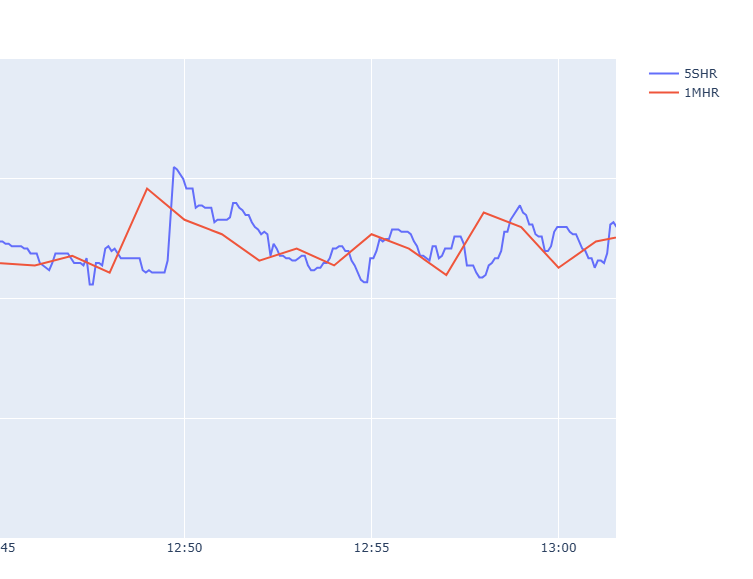

1 Min Heart Reate is using the average of the next minute. For example for min 13:40 it it get the average heart rate of the seconds
13:40:00 - 13:40:59 .

## Definitions / Inputs
<img src="../images/Screenshot Inputs.png"  />

## Time Structure
<img src="../images/Screenshot Time Structure.png"  />
 

## Conclusion
1. Since each input is generated in variable frequencies, a step to homogenize the time frequency has to be taken.
- later this has shown to decrease the accuracy
2. Mapping of the exercise could be difficult, since rep-counts can vary (if I lost focus on counting), did something in between ( tidy the machine, putting back the weights, transition to another machine, etc)
   Furthermore the heart rate will not increase immediately after an exercise has begun, but only steadily, depending of what kind of exercise
3. Since Weight and resting heart rate need a longer timespan (than the module 2) to show significant changes  I have skipped this analysis and focused on the exercise detection using heart rate and maybe steps

## Missing Values & Problem Statement
As stated in the summary, the main objective is to accurately measure the performance of the subject overtime, without having the additional effort to note down the training details, but the pulsemeter and maybe initial values to train the model at the beginning.
In the following picture you can see the training data: 
- In green: the training data given
- Red the missing timestamps, which should be estimated through the model. The assumption is, this is possible using only technical analysis ( positive change and negative change).
- Orange: The assumption is ML is required to detect the exercise type and the repetitions executed.

<img src="../images/Hand Notes.png"  />

### Possible solutions
1. mark the begin and end of a session this is only for validation, remove irrelevant data
2. the first spike during the session and the first (2 or 3 minutes pause ) is the first set
3. there after every other spike corresponds to another set
4. Enriching the data set, with the intensity of every exercise could increase the accuracy (after the first iteration of the DS Pipeline Circle)
5. Using Anomalies detection to cut-out non pauses between exercises.
6. Detect Pauses using pattern recognition (decline in Heart Rate beginning of a Pause and incline in the beginning of an exercise) or the percentage change of the heart rate (with a thresshold and shift)
7. Multiple weight_kg and Repetitions of the manual information are in the same column, therefore need to be broken down before analysis 
8. Accuracy of the time of exercises is not precise, and can deviate +-2mins

# Data cleansing & data transformation

Run data quality on your raw data. 

Here are some examples of possible data quality checks: 
- number of records (raws)
- number of fields (columns)
- range of data values (e.g. if your data contains the age of human beings, what would be an expected minimum and maximum values...)
- missing values & associated strategies (explain what you choose a specific strategy to deal with certain missing values)
- date values in the expected range
- distribution of values and outlyers detection


In [11]:
# Fix Order of Exercises in the hand notes and generate temporary Exercise Start Time to fill the gaps

# Initial column processing 
df_exercise = RAWDATAFILES["Manual Exercise:Training Notes.xlsx"].copy()

df_exercise = df_exercise.dropna(axis=0, how='all') #Delete all empty rows

df_exercise.insert(0, 'Order', np.arange(1, len(df_exercise)+1))
df_exercise["repetitions"] = df_exercise['repetitions'].astype(str)
df_exercise["weight_kg"] = df_exercise['weight_kg'].astype(str)
df_exercise["Time"] = df_exercise['Time'].astype(str)
df_exercise["Date"] = df_exercise['Date'].astype(str)
df_exercise["Est_Time"] =  df_exercise["Time"]
df_exercise["DateTime"] = pd.NaT

# Fill missing Time values
# 1. if first and last set is missing the time, set to Exercise Start End from ADD_TCX (this is to set the boundaries for interpolation
a =set(df_exercise["Date"])
b =  [item for item in a]
for cur_date in b:
    x=1
    xlist=[]
    for i in df_exercise.sort_values(by=["Order"]).index:
        #skip if not the current date
        if cur_date != df_exercise.at[i,"Date"]:
            continue
        #if first entry of the date
        if i==df_exercise[df_exercise["Date"]==cur_date].index.min():
            pcur_date= pd.to_datetime(cur_date, format="%d.%m.%Y" ).date()

            #time is empty
            if "nan" == df_exercise.at[i,"Time"]:
                df_exercise.iloc[i, df_exercise.columns.get_loc('Est_Time')]  = (ADD_TCX[pcur_date.strftime("%Y-%m-%d")]["StartTime"] + pd.Timedelta(minutes=5)).strftime("%H:%M") 
                print(f"set start time at i:{i} cur_date:{cur_date} to {df_exercise.iloc[i, df_exercise.columns.get_loc('Est_Time')] }")
        #if last entry of the date
        if i==df_exercise[df_exercise["Date"]==cur_date].index.max():
            #time is empty
            pcur_date= pd.to_datetime(cur_date, format="%d.%m.%Y" )

            if "nan" == df_exercise.at[i,"Time"]:
                df_exercise.iloc[i, df_exercise.columns.get_loc('Est_Time')]  = (ADD_TCX[pcur_date.strftime("%Y-%m-%d")]["EndTime"] - pd.Timedelta(minutes=10)).strftime("%H:%M")
                print(f"set end time at i:{i} cur_date:{cur_date} to {df_exercise.iloc[i, df_exercise.columns.get_loc('Est_Time')] }")
        

# 2. Interpolate Time
df_exercise["DateTime"]= df_exercise.apply(lambda row: ( pd.to_datetime(row['Date'] + " " + row['Time'], format="%d.%m.%Y %H:%M")) if row['Time']!="nan" else ( pd.to_datetime(row['Date'] + " " + row['Est_Time'], format="%d.%m.%Y %H:%M")) if row['Est_Time']!="nan" else  np.nan, axis=1).tolist()
df_exercise['Numeric_DateTime'] = pd.to_datetime(df_exercise['DateTime']).astype('int64')
df_exercise["Numeric_DateTime"]= df_exercise.apply(lambda row: ( np.nan) if row['Numeric_DateTime']<0 else row['Numeric_DateTime'], axis=1).tolist()
df_exercise['Numeric_DateTime'] = df_exercise['Numeric_DateTime'].interpolate(method='linear')
df_exercise['DateTime'] = pd.to_datetime(df_exercise['Numeric_DateTime'])
#df_exercise = df_exercise.drop(columns='Numeric_DateTime')

# 3. Valleys and Peaks to fill remaining missing times


#scipy.signal.find_peaks()

# Source - https://stackoverflow.com/q
# Posted by grimad, modified by community. See post 'Timeline' for change history
# Retrieved 2025-11-20, License - CC BY-SA 4.0

def process_peaks_and_valleys(y_data_array, peaks_indices, valleys_indices):
    # Ensures the first local extremum is a peak, I'm ok to lose a few datapoints in order to normalize all my file (starts with a peak and ends with a peak)
    while valleys_indices[0] < peaks_indices[0]:
        valleys_indices = np.delete(valleys_indices, 0)
    
    # Ensure the last local extremum is a peak
    while valleys_indices[-1] > peaks_indices[-1]:
        valleys_indices = np.delete(valleys_indices, -1)
    
    print('number of peaks pre-processing = ', len(peaks_indices), '; number of valleys = ', len(valleys_indices))
    
    # Loop through the peaks and valleys to ensure an alternating pattern (peak, valley, peak, valley...)
    i = 0
    while i < len(peaks_indices):
        while i + 1 < len(peaks_indices) and peaks_indices[i + 1] < valleys_indices[i]:
            # Delete the lowest peak between peaks_indices[i] and peaks_indices[i+1]
            peaks_indices = np.delete(peaks_indices, i if y_data_array[peaks_indices[i]] < y_data_array[peaks_indices[i+1]] else i+1)
            print('following peaks detected at indices ' + str(peaks_indices[i]) + ' and ' + str(peaks_indices[i+1]), '... deleting the lowest peak')
        i += 1
    
    # Repeat the process for valleys
    i = 0
    while i < len(valleys_indices):
        while i + 1 < len(valleys_indices) and valleys_indices[i + 1] < peaks_indices[i]:
            # Delete the highest valley between valleys_indices[i] and valleys_indices[i+1]
            valleys_indices = np.delete(valleys_indices, i if y_data_array[valleys_indices[i]] > y_data_array[valleys_indices[i+1]] else i+1)
            print('following valleys detected at indices ' + str(valleys_indices[i]) + ' and ' + str(valleys_indices[i+1]), '... deleting the highest valley')
        i += 1

    # Sort the updated indices
    valleys_indices.sort()
    peaks_indices.sort()
    print('\nnumber of peaks post-processing = ', len(peaks_indices), '; number of valleys = ', len(valleys_indices))
    return peaks_indices, valleys_indices



# Move Exercise to right date and generate temporary times based on Order
# a =set(df_exercise["Date"])
# b =  [item for item in a]
# for cur_date in b:
#     x=1
#     xlist=[]
#     for i in df_exercise.sort_values(by=["Order"]).index:

#         if cur_date != df_exercise.at[i,"Date"]:
#             continue
#         #print(f"{cur_date} {df_exercise.at[i,"Date"]}")
#         #print(df_exercise.at[i,"Est_Time"])
#         if ((df_exercise.at[i,"DateTime"]==np.nan) & ((pd.isna(df_exercise.at[i,"Est_Time"])) | (df_exercise.at[i,"Est_Time"]=="nan"))):
#             print(f"generated temporary time at i:{i} cur_date:{cur_date} x:{x}")
#             if(x<10):
#                 df_exercise.iloc[i, df_exercise.columns.get_loc('Est_Time')]  = "00:0"+str(x)
#             else:
#                 df_exercise.iloc[i, df_exercise.columns.get_loc('Est_Time')] = "00:"+str(x)
#             x+=1

df_exercise["Interpolation_DateTime"]= df_exercise["Est_Time"]
df_exercise["Est_Accuracy"]= np.where( df_exercise["Time"].isna(),0,0.9)
df_exercise["Est_Probability"]= np.where( df_exercise["Time"].isna(),0,0.9)


set start time at i:0 cur_date:5.11.2025 to 11:25
set end time at i:9 cur_date:5.11.2025 to 12:52
set end time at i:76 cur_date:13.11.2025 to 17:47
set start time at i:24 cur_date:7.11.2025 to 14:24
set end time at i:32 cur_date:7.11.2025 to 16:08
set start time at i:77 cur_date:14.11.2025 to 15:04
set start time at i:86 cur_date:17.11.2025 to 10:43
set end time at i:93 cur_date:17.11.2025 to 12:27
set start time at i:10 cur_date:6.11.2025 to 11:25
set end time at i:23 cur_date:6.11.2025 to 13:27


In [12]:
print(ADD_TCX["2025-11-05"])
print(df_exercise[['Date','Time','Est_Time','DateTime','Interpolation_DateTime','Est_Accuracy','Est_Probability']].head(30) )
print(df_exercise[['Date','Time','Est_Time','DateTime','Interpolation_DateTime','Est_Accuracy','Est_Probability']].tail(30) )
print("last datapoint: " + str(RAWDATAFILES["Health Sync Activities:" + LastTCXFile]["Time"].max()))

{'StartTime': Timestamp('2025-11-05 11:20:18'), 'EndTime': Timestamp('2025-11-05 13:02:52'), 'TriggerMethod': 'Manual', 'calories': 923, 'TotalTimeSeconds': 6161, 'Intensity': 'Active', 'AverageHeartRateBpm': '132', 'MaximumHeartRateBpm': '165'}
         Date   Time Est_Time            DateTime Interpolation_DateTime  \
0   5.11.2025    nan    11:25 2025-11-05 11:25:00                  11:25   
1   5.11.2025    nan      nan 2025-11-05 11:34:40                    nan   
2   5.11.2025    nan      nan 2025-11-05 11:44:20                    nan   
3   5.11.2025    nan      nan 2025-11-05 11:54:00                    nan   
4   5.11.2025    nan      nan 2025-11-05 12:03:40                    nan   
5   5.11.2025    nan      nan 2025-11-05 12:13:20                    nan   
6   5.11.2025    nan      nan 2025-11-05 12:23:00                    nan   
7   5.11.2025    nan      nan 2025-11-05 12:32:40                    nan   
8   5.11.2025    nan      nan 2025-11-05 12:42:20                    n

In [13]:
#Merge files of the same parent folder
col_signature={}

for element in RAWDATAFILES:
    parent_folder= element.split(':')[0]
    if (len(col_signature)==0) | (parent_folder not in col_signature):
        col_signature[parent_folder]=[]   
    cur_list= col_signature[parent_folder]
    cur_list.append(element)
    col_signature[parent_folder] =cur_list
    
for sig in col_signature:
    MERGEDDATAFILES[sig] = pd.concat([RAWDATAFILES[col_sig] for col_sig in col_signature[sig]], axis=0,join="outer")


In [14]:
#Generate dummy Series for Resampling
#Entire Date Range set here:
start_date = date(2025, 11, 3) 
end_date = date.today() #date(2025, 11, 10)    # perhaps 

delta = end_date - start_date   # returns timedelta
sample = []
ticks = pd.concat( pd.date_range( start=(start_date + timedelta(days=i)).strftime("%Y-%m-%d") + " 09:00:00", end=(start_date + timedelta(days=i)).strftime("%Y-%m-%d") + " 21:00:00", freq='5s').to_series() for i in range(delta.days + 1) )

for x in range(len(ticks)):
    sample.append(np.nan)

main_df = pd.DataFrame.from_dict({"HeartRate BPM": np.array(sample),"DateTime": ticks})

# Other Solution:
# %%timeit -r 10
# hourly_index4 = pd.date_range(daily_index.start_time.min(), 
#                               daily_index.end_time.max() + pd.DateOffset(days=1), 
#                               normalize=True, freq='H')
# overlap = np.in1d(np.array(hourly_index4.values, dtype='datetime64[D]'),
#                   np.array(daily_index.start_time.values, dtype='datetime64[D]'))
# hourly_index4 = hourly_index4[overlap]

------------------------------Health Sync Activities------------------------------
Dropped:HeartRateBpm
Dropped:Time
Renamed:5SHR
------------------------------Health Sync Summary------------------------------
Dropped:Source app
Dropped:Activity type
Dropped:Activity name
Dropped:Date
Dropped:Time
Dropped:Elapsed time
Dropped:Active time
Dropped:Distance (miles)
Dropped:Calories (kcal)
Dropped:Steps
Dropped:Average heart rate
Dropped:Max heart rate
Dropped:Average speed
Dropped:Max speed
Renamed:Avg HR
Renamed:Max HR
------------------------------Health Sync Heart rate------------------------------
Dropped:Date
Dropped:Time
Dropped:Heart rate
Dropped:Source
Renamed:1MHR
------------------------------Health Sync Steps------------------------------
Dropped:Date
Dropped:Time
Dropped:Steps
Renamed:Steps
------------------------------Health Sync Weight------------------------------
Dropped:Date
Dropped:Time
Dropped:Weight
Dropped:Body fat percentage
Dropped:Body fat mass
Dropped:Fat free pe

c:\Users\pasca\AppData\Local\Programs\Python\Python313\Lib\site-packages\pandas\plotting\_matplotlib\core.py:981: UserWarning: This axis already has a converter set and is updating to a potentially incompatible converter
  return ax.plot(*args, **kwds)


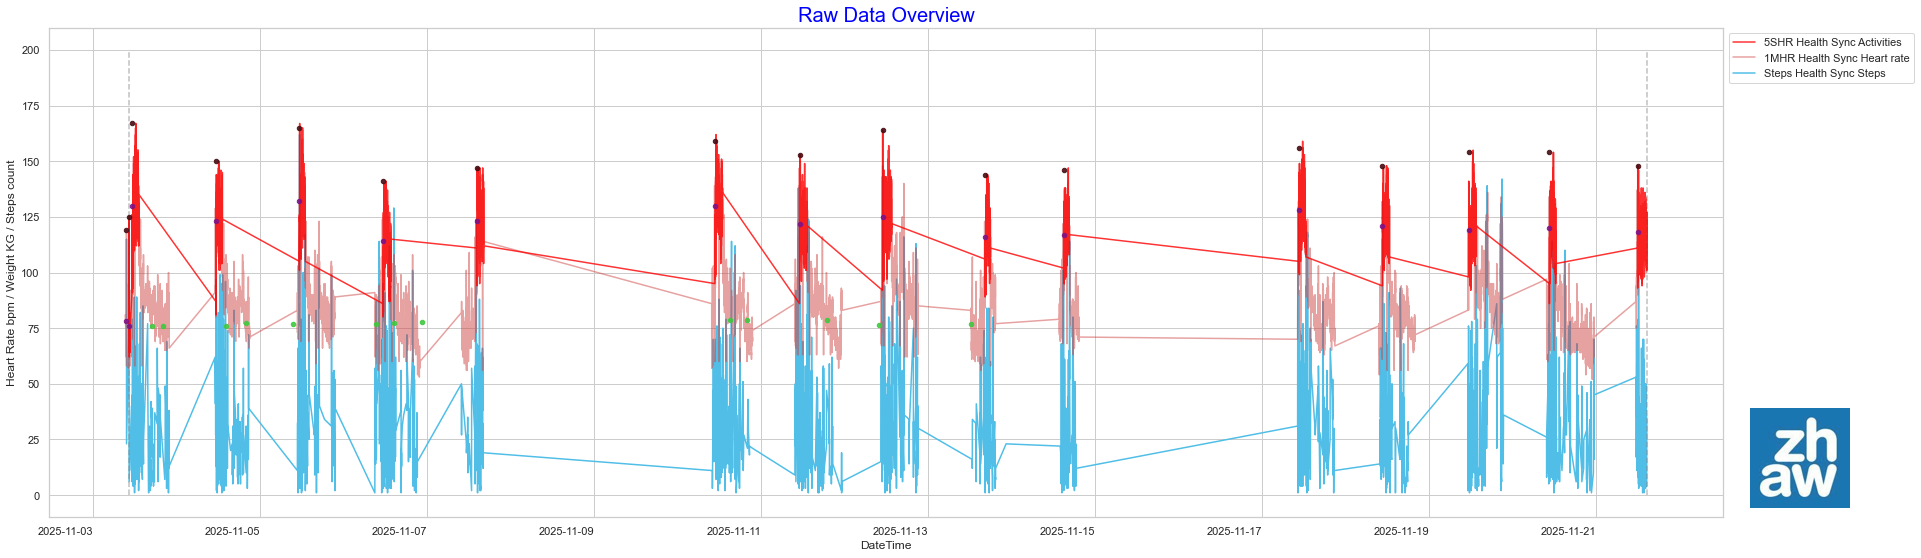

In [15]:
#Visual Validation
step_count_raw = 0

#Seaborn Matplotlib Original Solution
sns.set_theme(style="whitegrid")
plt.figure(figsize=(30,10), dpi=72)
ax = sns.lineplot(main_df,x = 'DateTime',y="HeartRate BPM")

#Cleansing & parameters for visual overview 
for element in MERGEDDATAFILES:
    
    print("---"*10 + element + "---"*10)
    if MERGEDDATAFILES[element].shape[0] > 0: #number of records check
        right_df = MERGEDDATAFILES[element].copy()
        #right_df.info()
        #---------------------------------------used for grouping later ---------------------
        #right_df["File"] = element 

        #Format Axis according to Data type
        if "exercise" in right_df.columns:
            continue
        
        if "Date" in right_df.columns:
            right_df.dropna(subset=["Date"],inplace=True)
            try:
                right_df["DateTime"] = pd.to_datetime(right_df["Date"],format="%Y.%m.%d %H:%M:%S")
            except:
                if "Time" in right_df.columns:
                    right_df["DateTime"] = pd.to_datetime(right_df["Date"] + right_df["Time"],format="%d.%m.%Y %H:%M:%S")
                else:
                    right_df["DateTime"] = pd.to_datetime(right_df["Date"],format="%d.%m.%Y")

            if ("Steps" in right_df.columns) & (element != "Health Sync Summary"):
                right_df.dropna(subset=["Steps"],inplace=True)
                right_df["Steps " + element] = pd.to_numeric(right_df['Steps'])
                ylist=["Steps " + element]
                mode='lines'
                kind="line"
                zorder=1
                alpha=1
                color="#50bee6"
                right_df.plot(x='DateTime', y=ylist, ax=ax,kind=kind,zorder=zorder, alpha=alpha,color=color)
                step_count_raw = step_count_raw + right_df["Steps"].count()

            if (("Heart rate" in right_df.columns) & (element=="Health Sync Heart rate")): #Whole day
                right_df.dropna(subset=["Heart rate"],inplace=True)
                right_df["1MHR " + element ] = pd.to_numeric(right_df['Heart rate'])
                ylist=["1MHR " + element ]
                mode='markers'
                kind="line"
                zorder=2
                alpha=0.5
                color="#cf4444"
                right_df.plot(x='DateTime', y=ylist, ax=ax,kind=kind,zorder=zorder, alpha=alpha,color=color)

            if "Weight" in right_df.columns:
                right_df.dropna(subset=["Weight"],inplace=True)
                right_df["Weight "+ element] = pd.to_numeric(right_df["Weight"])
                right_df["Weight "+ element] = right_df["Weight "+ element] * 0.45359237
                if right_df["Weight "+ element].max() >100 : print("Error Weight")
                if right_df["Weight "+ element].min() <20 : print("Error Weight")
                ylist=["Weight "+ element]
                kind="scatter"
                zorder=10
                alpha=0.9
                color="#3ec93e"
                right_df.plot(x='DateTime', y=ylist, ax=ax,kind=kind,zorder=zorder, alpha=alpha,color=color)

            if "Average heart rate" in right_df.columns:
                right_df.dropna(subset=["Average heart rate"],inplace=True)
                try:
                    right_df["Avg HR "+ element ]=pd.to_numeric(right_df['Average heart rate'])
                except:
                    print("error: " + right_df[['Average heart rate']])
                    print(right_df)
                ylist=["Avg HR "+ element ]
                mode='markers'
                kind="scatter"
                zorder=9
                alpha=0.9
                color="#7f1287"
                right_df.plot(x='DateTime', y=ylist, ax=ax,kind=kind,zorder=zorder, alpha=alpha,color=color)

            if "Max heart rate" in right_df.columns:
                right_df.dropna(subset=["Max heart rate"],inplace=True)
                right_df["Max HR " + element]=pd.to_numeric(right_df['Max heart rate'])
                ylist=["Max HR "+ element ]
                mode='markers'
                kind="scatter"
                zorder=10
                alpha=0.9
                color="#470d13"
                right_df.plot(x='DateTime', y=ylist, ax=ax,kind=kind,zorder=zorder, alpha=alpha,color=color)

        elif (("Time" in right_df.columns) & (element==("Health Sync Activities"))):
            right_df.dropna(subset=['Time'],inplace=True)
            right_df["DateTime"] = pd.to_datetime(right_df["Time"] ,format="%Y.%m.%d %H:%M:%S")
            if "HeartRateBpm" in right_df.columns:    #Training Session
                right_df.dropna(subset=['HeartRateBpm'],inplace=True)
                right_df["5SHR "+ element]=pd.to_numeric(right_df['HeartRateBpm'])
                ylist=["5SHR "+ element]
                mode='lines+markers'
                kind="line"
                zorder=3
                alpha=0.8
                color="#FF0000"
                plt.vlines(right_df["Time"].min(), 0, 200, linestyles ="dashed", colors ="grey", alpha=0.5)
                plt.vlines(right_df["Time"].max(), 0, 200, linestyles ="dashed", colors ="grey", alpha=0.5)
                right_df.plot(x='DateTime', y=ylist, ax=ax,kind=kind,zorder=zorder, alpha=alpha,color=color)

        #drop unused columns and rename the used ones    
        for col in right_df.columns:
            if ((col.find(element)<0) | (element.find("Weight")>0)):
                if col != "DateTime":
                    right_df.drop(columns=col,axis=1, inplace=True)
                    print("Dropped:" + col)
            else:
                print("Renamed:" + right_df[col].name.replace(str(element),"").rstrip())
                right_df.rename(columns={right_df[col].name:right_df[col].name.replace(str(element),"").rstrip()}, inplace=True)
        
        # Solution using Homogenized 5s Tick
        # Since there is not much missing data in between the days and the days can be displayed independently this is not necessary
        #plot_daily = pd.merge_asof(left=main_df, right=right_df.sort_values("DateTime"), on='DateTime')
        #plot_daily.resample('5s', on='DateTime')
        #plot_daily.set_index("DateTime",inplace=True)
        HOMOGENIZEDDATAFILES[element] = right_df.sort_values("DateTime").copy() #plot_daily.copy()
    else: print("Element skipped due to 0 rows:" + element)

#move the legend to the right
sns.move_legend(ax, "upper left", bbox_to_anchor=(1, 1))

#adjust the size of the chart
#plt.rcParams['figure.dpi'] = 600
#plt.rcParams['savefig.dpi'] = 600

# add a title, set the font size and color
ax.set_title("Raw Data Overview", color="blue", fontsize=20)
ax.set_ylabel("Heart Rate bpm / Weight KG / Steps count")


response = requests.get('https://nico.nexgate.ch/images/logo.jpg')
img = Image.open(BytesIO(response.content))
# resize the image to 40x40 pixels
img = img.resize((100, 100))
plt.figimage(img, 1750, 50, zorder=3, alpha=.9)

# position the logo on the bottom right and adjust the transparency
figure = plt.gcf()
figure.set_size_inches(30,10)

plt.show()

In [16]:
#Merge dataframes into one 

# Counts prior to merging
Steps_count_before=HOMOGENIZEDDATAFILES["Health Sync Steps"]["Steps"].count()


#Working solution
main_df=pd.concat(list(HOMOGENIZEDDATAFILES.values()))
main_df.sort_values("DateTime",inplace=True)

#Old Solution
#main_df.columns= main_df.columns = [' '.join(col).strip() for col in main_df.columns.values]
#main_df.drop(columns=main_df.columns.difference(keep_cols), inplace=True)
# for col in main_df.columns:
#     if col[1] not in keep_cols:
#         main_df.drop(col.index)

#new solution (produces duplicates)
#from functools import reduce
#main_df = reduce(lambda  left,right: pd.merge(left,right, on='DateTime', how='outer',sort=True), list(HOMOGENIZEDDATAFILES.values()))

#main_df.sort_values("DateTime",inplace=True)
#main_df.resample('5s', on='DateTime')
#main_df.set_index("DateTime",inplace=True)
#main_df.reset_index(inplace=True) 


In [17]:
# DQ Validation After Merging
print(f"Step counts raw: {step_count_raw} before merge: {Steps_count_before} after merge: {main_df["Steps"].count()}. ")
print(main_df[main_df["Steps"].isnull()==False].count()) 
print(main_df.columns)
print(main_df.count())

Step counts raw: 2427 before merge: 2427 after merge: 2427. 
DateTime    2427
5SHR           0
Avg HR         0
Max HR         0
1MHR           0
Steps       2427
dtype: int64
Index(['DateTime', '5SHR', 'Avg HR', 'Max HR', '1MHR', 'Steps'], dtype='object')
DateTime    33615
5SHR        22234
Avg HR         17
Max HR         17
1MHR         8924
Steps        2427
dtype: int64


In [18]:
# Moving Window Detector
from skchange.change_detectors import MovingWindow
from skchange.change_scores import CUSUM

# cusum = measures the difference in mean between two intervals
#detector = MovingWindow(change_score=CUSUM() bandwidth=4)
detector = MovingWindow(bandwidth=10)
detector.fit(main_df[["5SHR"]].dropna().values)
detections = detector.predict(main_df[["5SHR"]].dropna().values)
#main_df.iloc[list(detections["ilocs"])]

print("---"*10 + "Change Detection Results" + "---"*10)
print(main_df.dropna(subset="5SHR").iloc[list(detections["ilocs"])])
print("Detections amount: " + str(detections["ilocs"].count()) )


------------------------------Change Detection Results------------------------------
                DateTime   5SHR  Avg HR  Max HR  1MHR  Steps
15   2025-11-03 10:22:15   83.0     NaN     NaN   NaN    NaN
30   2025-11-03 10:23:30   99.0     NaN     NaN   NaN    NaN
45   2025-11-03 10:24:45   88.0     NaN     NaN   NaN    NaN
78   2025-11-03 10:27:30   65.0     NaN     NaN   NaN    NaN
1    2025-11-03 11:16:42  122.0     NaN     NaN   NaN    NaN
...                  ...    ...     ...     ...   ...    ...
1831 2025-11-21 14:30:32  115.0     NaN     NaN   NaN    NaN
1848 2025-11-21 14:31:57  118.0     NaN     NaN   NaN    NaN
1892 2025-11-21 14:35:37  110.0     NaN     NaN   NaN    NaN
1919 2025-11-21 14:37:53  122.0     NaN     NaN   NaN    NaN
1949 2025-11-21 14:40:23  109.0     NaN     NaN   NaN    NaN

[893 rows x 6 columns]
Detections amount: 893


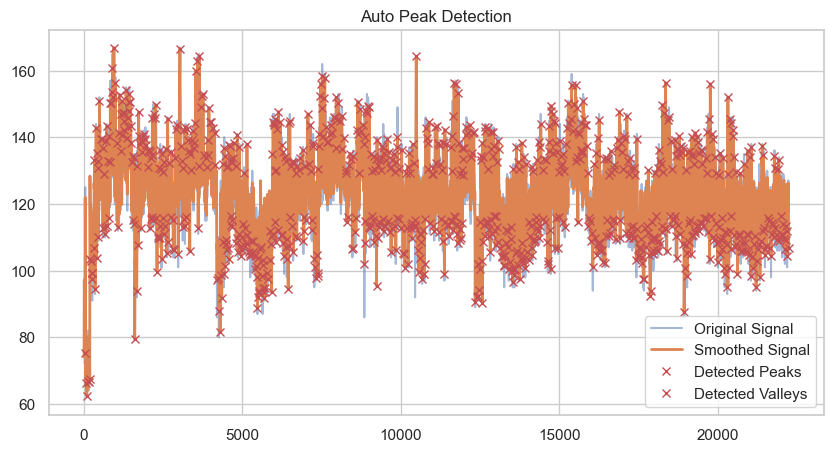

Peak indices: [  328   381   412   428   438   487   531   573   610   640   696   714
   750   790   813   829   851   875   894   918   942   991  1030  1093
  1120  1154  1172  1182  1201  1238  1251  1266  1276  1326  1340  1373
  1383  1404  1416  1426  1444  1473  1492  1518  1538  1590  1683  1724
  1735  1769  1804  1839  1862  1897  1936  1968  2011  2028  2042  2088
  2122  2133  2156  2193  2224  2262  2360  2401  2424  2475  2501  2538
  2589  2639  2687  2753  2870  2892  2946  3026  3062  3098  3129  3161
  3201  3242  3283  3315  3348  3377  3399  3438  3475  3485  3503  3524
  3576  3615  3633  3675  3714  3752  3788  3848  3883  3899  3911  3940
  3973  4010  4061  4117  4145  4388  4424  4454  4508  4542  4578  4611
  4631  4647  4695  4727  4782  4835  4901  5052  5141  5944  5965  5983
  6002  6023  6041  6067  6082  6136  6190  6234  6288  6336  6380  6458
  6492  6520  6566  6635  6690  6730  6776  6830  6905  6967  7067  7096
  7136  7156  7220  7230  7378  7404 

In [19]:

from scipy.signal import find_peaks, savgol_filter

def auto_find_peaks(signal, sampling_rate=1.0, smooth_window=11, poly_order=3):
    """
    Automatically smooths and detects peaks in a signal.

    Parameters:
        signal (array-like): Input signal data.
        sampling_rate (float): Samples per unit (Hz if time series).
        smooth_window (int): Window length for Savitzky-Golay smoothing (must be odd).
        poly_order (int): Polynomial order for smoothing.

    Returns:
        peaks (ndarray): Indices of detected peaks.
        properties (dict): Peak properties from scipy.signal.find_peaks.
    """
    signal = np.asarray(signal)

    # Validate parameters
    if smooth_window >= len(signal):
        smooth_window = len(signal) - (1 - len(signal) % 2)  # Ensure odd and < len(signal)
    if smooth_window < 3:
        smooth_window = 3

    # Smooth the signal to reduce noise
    smoothed = savgol_filter(signal, smooth_window, poly_order)

    # Auto threshold: use mean + std as a starting point
    height_threshold = np.mean(smoothed) + 0.5 * np.std(smoothed)

    # Auto minimum distance: avoid detecting peaks too close
    min_distance = int(sampling_rate * 0.1)  # e.g., 0.1 seconds apart

    # Detect peaks
    peaks, properties = find_peaks(
        smoothed,
        height=height_threshold,
        distance=min_distance,
        prominence=np.std(smoothed) * 0.3
    )

    return peaks, properties, smoothed

# Example usage
if __name__ == "__main__":
    # Create a noisy test signal
    x = main_df['5SHR'].dropna().index.values
    y = main_df['5SHR'].dropna().values 
    y_valleys = main_df['5SHR'].dropna().values *-1 

    peaks, props, smoothed = auto_find_peaks(y, sampling_rate=500/ (6*np.pi))
    peaks_v, props_V, smoothed_v = auto_find_peaks(y_valleys, sampling_rate=500/ (6*np.pi))

    # Plot results
    plt.figure(figsize=(10, 5))
    plt.plot(y, label="Original Signal", alpha=0.5)
    plt.plot(smoothed, label="Smoothed Signal", linewidth=2)
    plt.plot(peaks, smoothed[peaks], "rx", label="Detected Peaks")
    plt.plot(peaks_v, smoothed[peaks_v], "rx", label="Detected Valleys")
    plt.legend()
    plt.title("Auto Peak Detection")
    plt.show()

    print("Peak indices:", peaks)
    print("Peak heights:", props["peak_heights"])


# How it works

# Smoothing: Uses savgol_filter to reduce noise without distorting peaks.
# Adaptive thresholds:

# height is set to mean + 0.5 × std of the smoothed signal.
# prominence is proportional to the signal’s standard deviation.
# distance is based on sampling rate to avoid false multiple detections.


# Output: Returns peak indices, their properties, and the smoothed signal.


# ✅ This approach works well for autofit peak detection in many real-world signals (sensor data, biomedical signals, vibration analysis, etc.) without manually tuning parameters every time.
# If you want, I can also give you a version that automatically estimates the optimal smoothing window and prominence using signal statistics — making it even more “hands-off.”
# Do you want me to prepare that?


In [20]:
#Correlation between steps and heart rate
# calculate the Pearson's correlation between two variables
from numpy.random import randn
from numpy.random import seed
from scipy.stats import pearsonr, spearmanr

from functools import reduce


cor_df = reduce(lambda  left,right: pd.merge(left,right, on='DateTime', how='outer',sort=True), list([main_df.dropna(subset=["Steps"])[["DateTime","Steps"]], main_df.dropna(subset=["1MHR"])[["DateTime","1MHR"]]]) )
cor_df.sort_values(by="DateTime",inplace=True)


for file in ADD_TCX:
    print("---"*10 + "Correlation Analysis for Training on " + file + "---"*10) 
    #filter only data during training
    maskTime = (cor_df["DateTime"] >= ADD_TCX[file]["StartTime"]) & (cor_df["DateTime"] <= ADD_TCX[file]["EndTime"])
    data1 = cor_df[maskTime]['Steps'].fillna(0)
    data2 =  cor_df[maskTime]['1MHR'].fillna(0)

    # covariance = np.cov(data1, data2)
    # print(covariance)

    # calculate Pearson's correlation
    corr1, _ = pearsonr(data1, data2)
    print(corr1)
    if corr1 >= 0.1:
        print("Low Pearson Correlation in " + file + ' %.3f' % corr1)
    if ((corr1 < 0.1) & (corr1 >-0.1)):
        print("No Pearson Correlation in " + file + ' %.3f' % corr1)
    if corr1 <= -0.1:
        print("Low Pearson inversed correlation in " + file + ' %.3f' % corr1)

    # calculate Spearman's Rank correlation
    corr2, _ = spearmanr(data1, data2)
    print(corr2)
    if corr2 >= 0.1:
        print("Low Spearman Rank Correlation in " + file + ' %.3f' % corr2)
    if ((corr2 < 0.1) & (corr2 >-0.1)):
        print("No Spearman Rank Correlation in " + file + ' %.3f' % corr2)
    if corr2 <= -0.1:
        print("Low Spearman Rank inversed correlation in " + file + ' %.3f' % corr2)

print("Overall Correlation between Steps and Heart Rate during Training Sessions is low or none.")

#main_df["COR_StepHR"]= main_df[['Steps','1MHR']].corr()

------------------------------Correlation Analysis for Training on 2025-11-03------------------------------
-0.13336866483732648
Low Pearson inversed correlation in 2025-11-03 -0.133
-0.11450578734438818
Low Spearman Rank inversed correlation in 2025-11-03 -0.115
------------------------------Correlation Analysis for Training on 2025-11-04------------------------------
-0.042150442063926014
No Pearson Correlation in 2025-11-04 -0.042
-0.019298605237081483
No Spearman Rank Correlation in 2025-11-04 -0.019
------------------------------Correlation Analysis for Training on 2025-11-05------------------------------
0.16964268354287873
Low Pearson Correlation in 2025-11-05 0.170
-0.023557746327447848
No Spearman Rank Correlation in 2025-11-05 -0.024
------------------------------Correlation Analysis for Training on 2025-11-06------------------------------
-0.008337498355133775
No Pearson Correlation in 2025-11-06 -0.008
-0.0647854964967622
No Spearman Rank Correlation in 2025-11-06 -0.065
--

# Visualization

- Choose and justify why you are using specific visualizaitons for your project.
- Add comments to explain what we learn from the data visualization. 


## Chart Type Selection
The classic horizontal time axis was chosen to plot the different inputs in the y axis.
Since I want to check the plausibility of the data and second to check the correlation between pulse and steps, as well as the daily boundaries.<br>
Also using the time slider, the preferred time range can easily be selected, and one can zoom in to the details, negating the amount of data presented.
It was very usefull to compare hand notes (approximation), interpolation and moving window algorithm time points / slices.
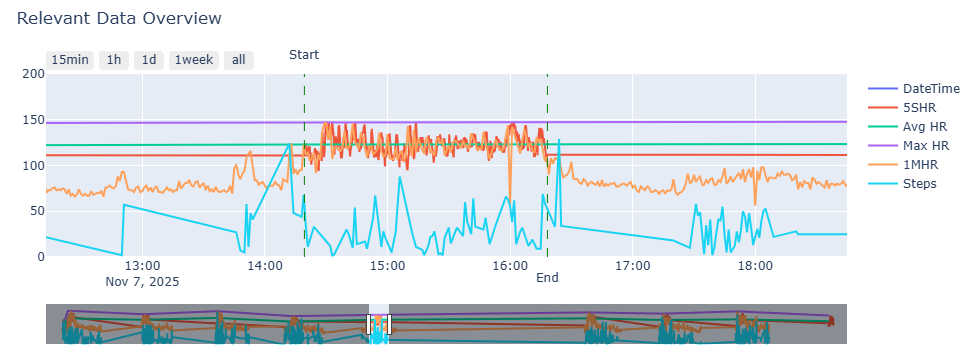


## Correlation between Steps and Heart Rate
As 1 Min Frequency of additional Step data can not be a help to increase the accuracy of the timing of the exercises.
It might could be usefull to determine, whether during that minute the heart rate has increased due to walking (correlated) or rather execution of the excercises (inversly correlated). As the correlation itself is insignificant, as shown in the analysis the idea to use it as validation is scrapped:

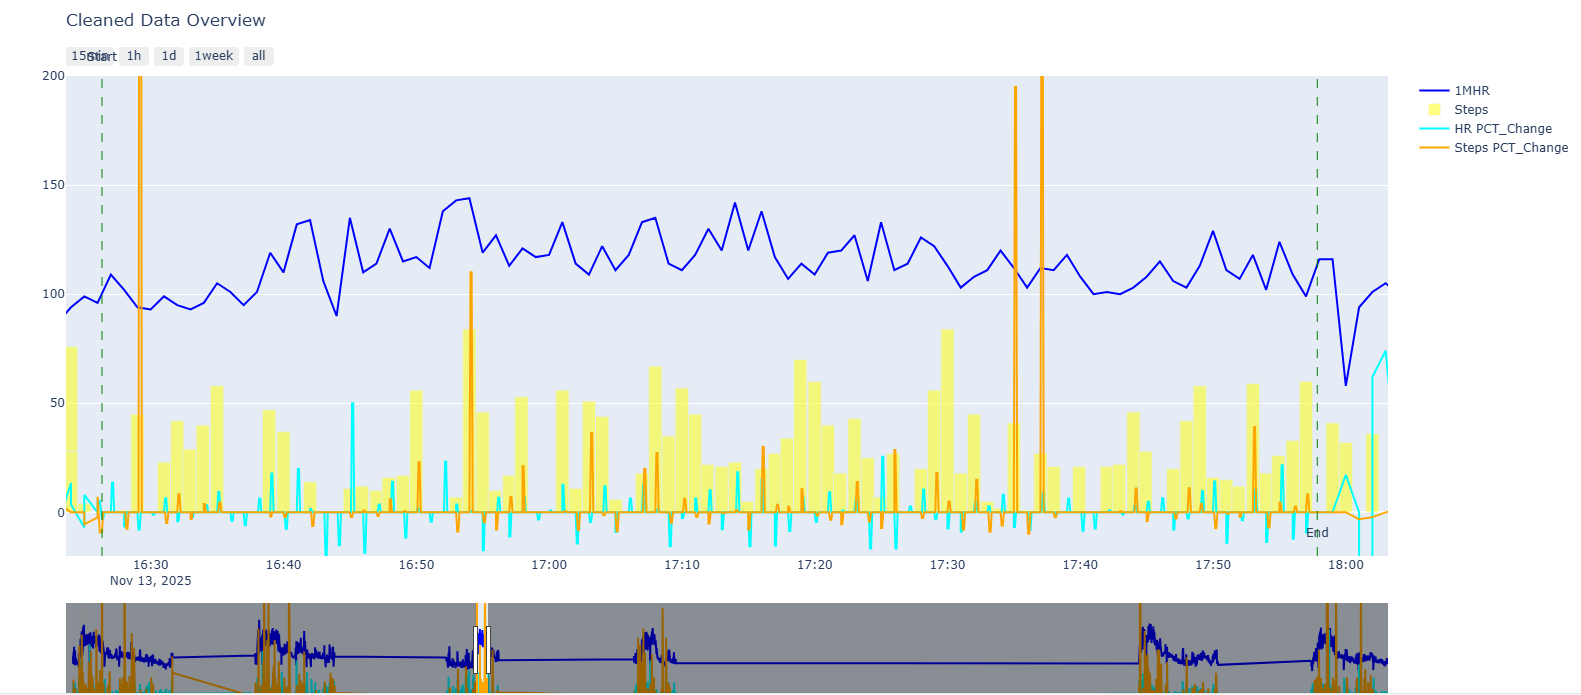


## Interpolated Timestamps

Using linear interpolation, the missing <b>start</b> timestamps for exercises has been interpolated.

Here you can see the noted timestamp and the interpolated timestamp thereafter.

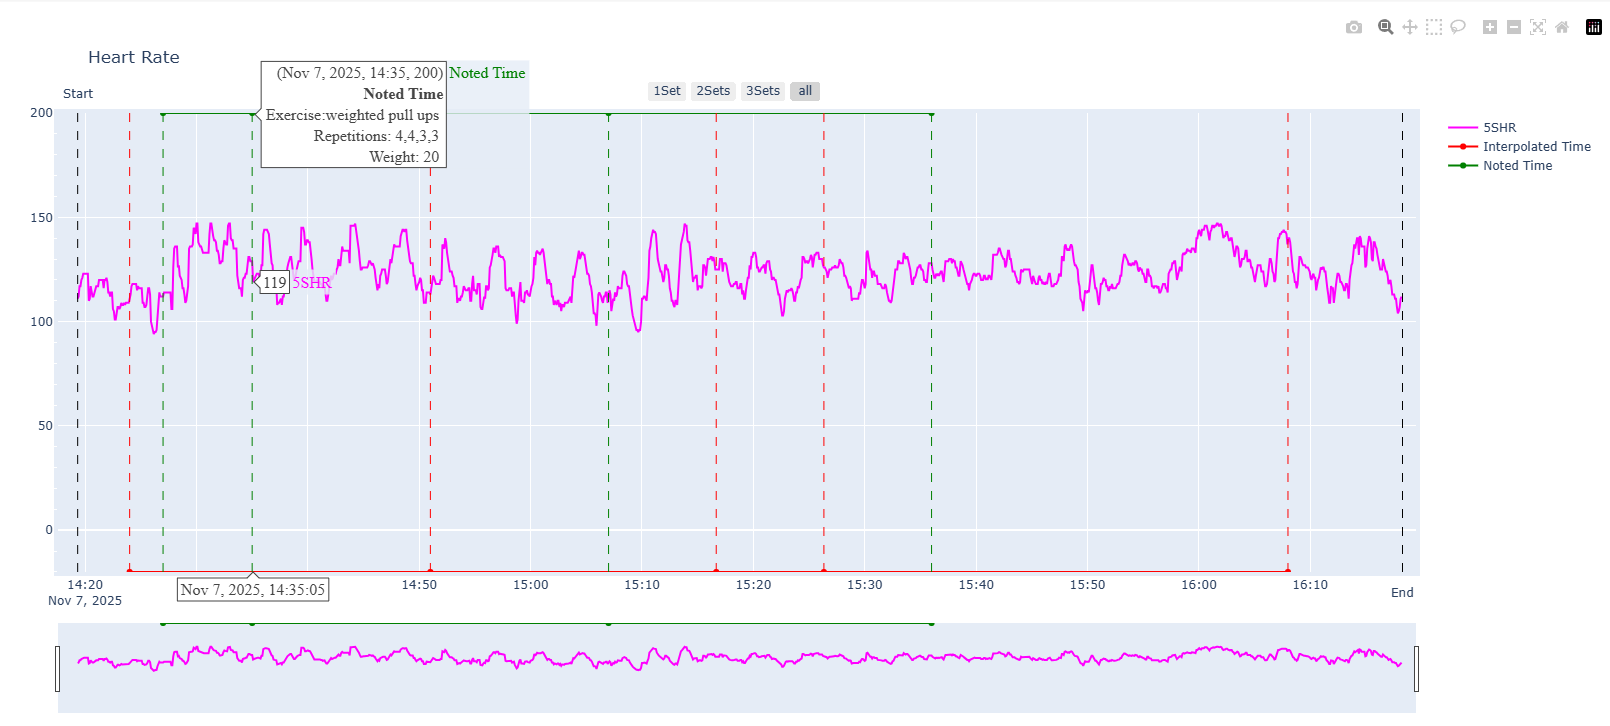
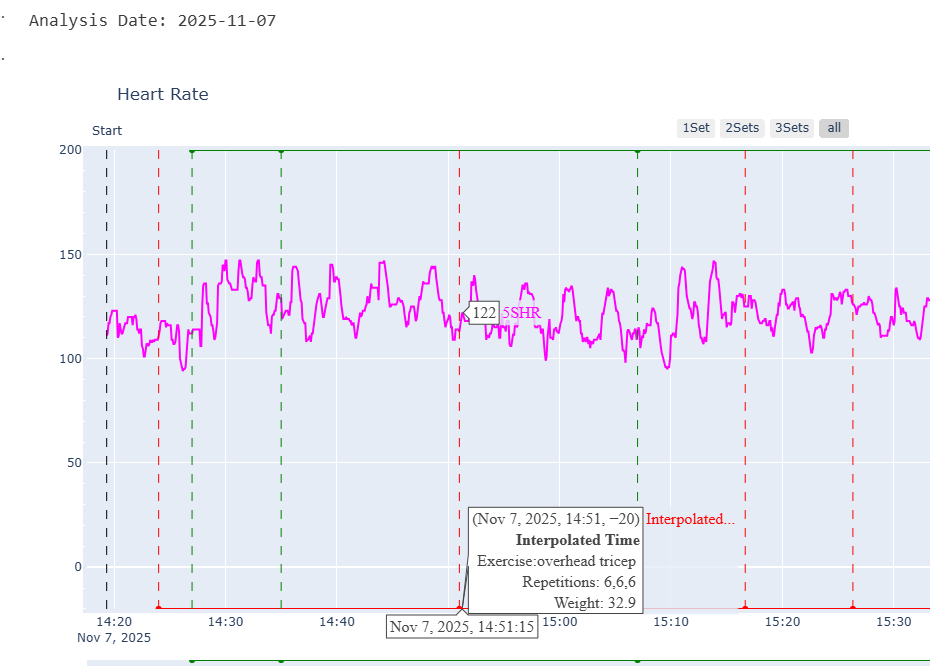

As you can see the approximation is plausible, as the exercise before has 4 sets and after the interpolated timestamp, there is a mistake of as 1 set has not been noted down. It could be either a extra set of the exercise with the interpolated timestamp or the set after.

## Moving Window Detection
This is the first attempt to increase the accuracy of the start timestamps using an algorithm.<br>
The moving window takes the mean of a certain window and compares to a shifted window.
If the delta of the both the means is above a certain threshold it will generate a new detection between the windows.
<br>
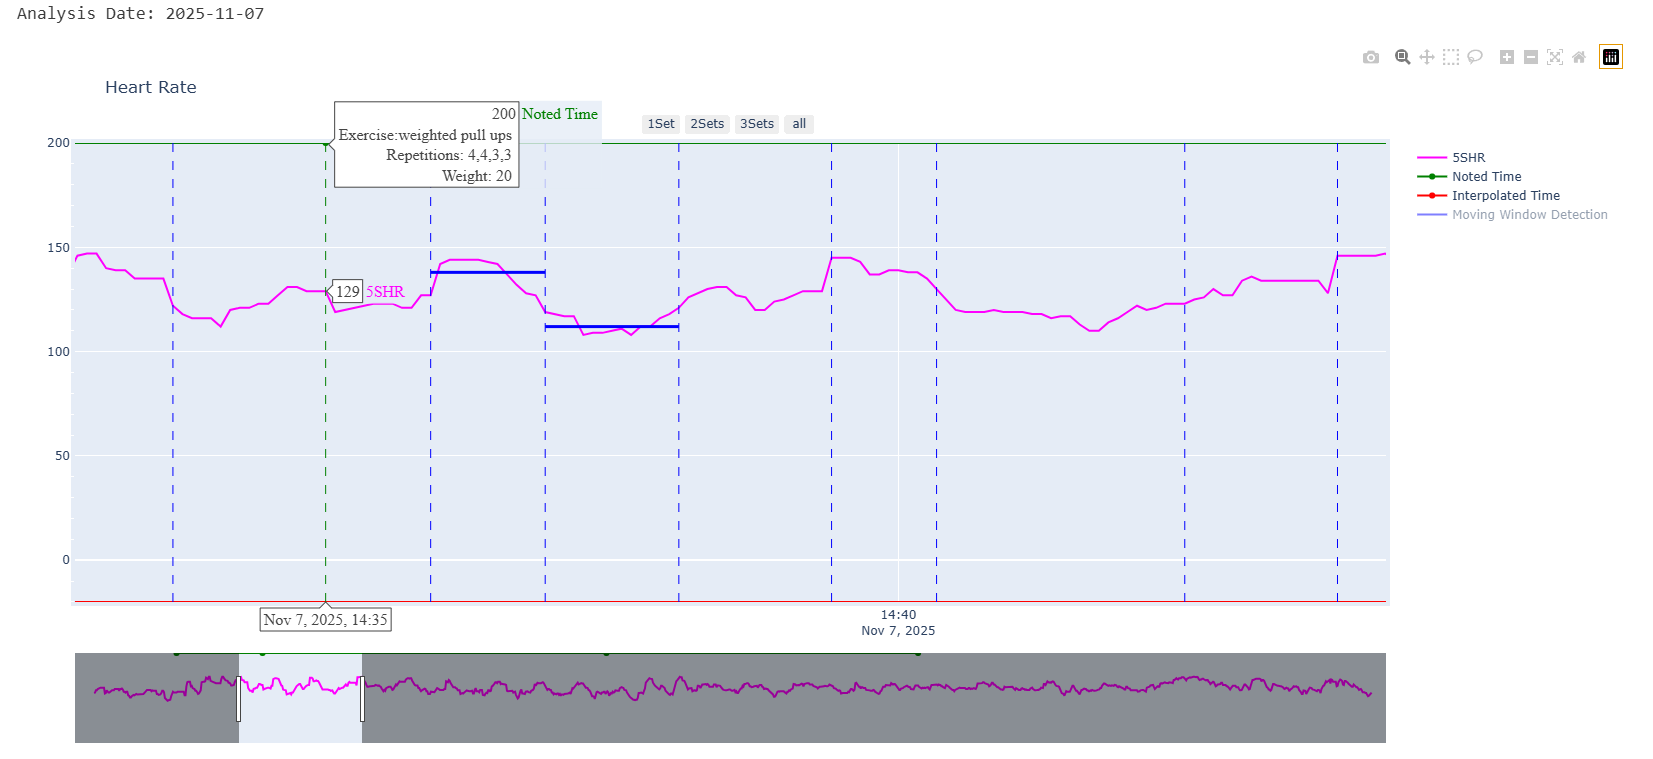
<br>
It correctly detected the break between the 2 excercises (12 repetition / longer duration and 6 repetitions / shorter duration as noted):
<br>
On the other hand it also produces a lot of false-positives, due anomalies in the data, which require further deep dive and goes beyond the time limit of this module.
The accuracy is as expected, as it doesn't understand the excercise actually start in the valley and ends when the pulse drop off.
Instead the algorithm just the cut of between the 2 means, therefore additional finetuning, e.g. looking back and ahead, also taking in consideration the repetitions of each set can help. This would require further data cleansing and Machine learning (next module maybe).
<br>

## Peak and Valley Detection
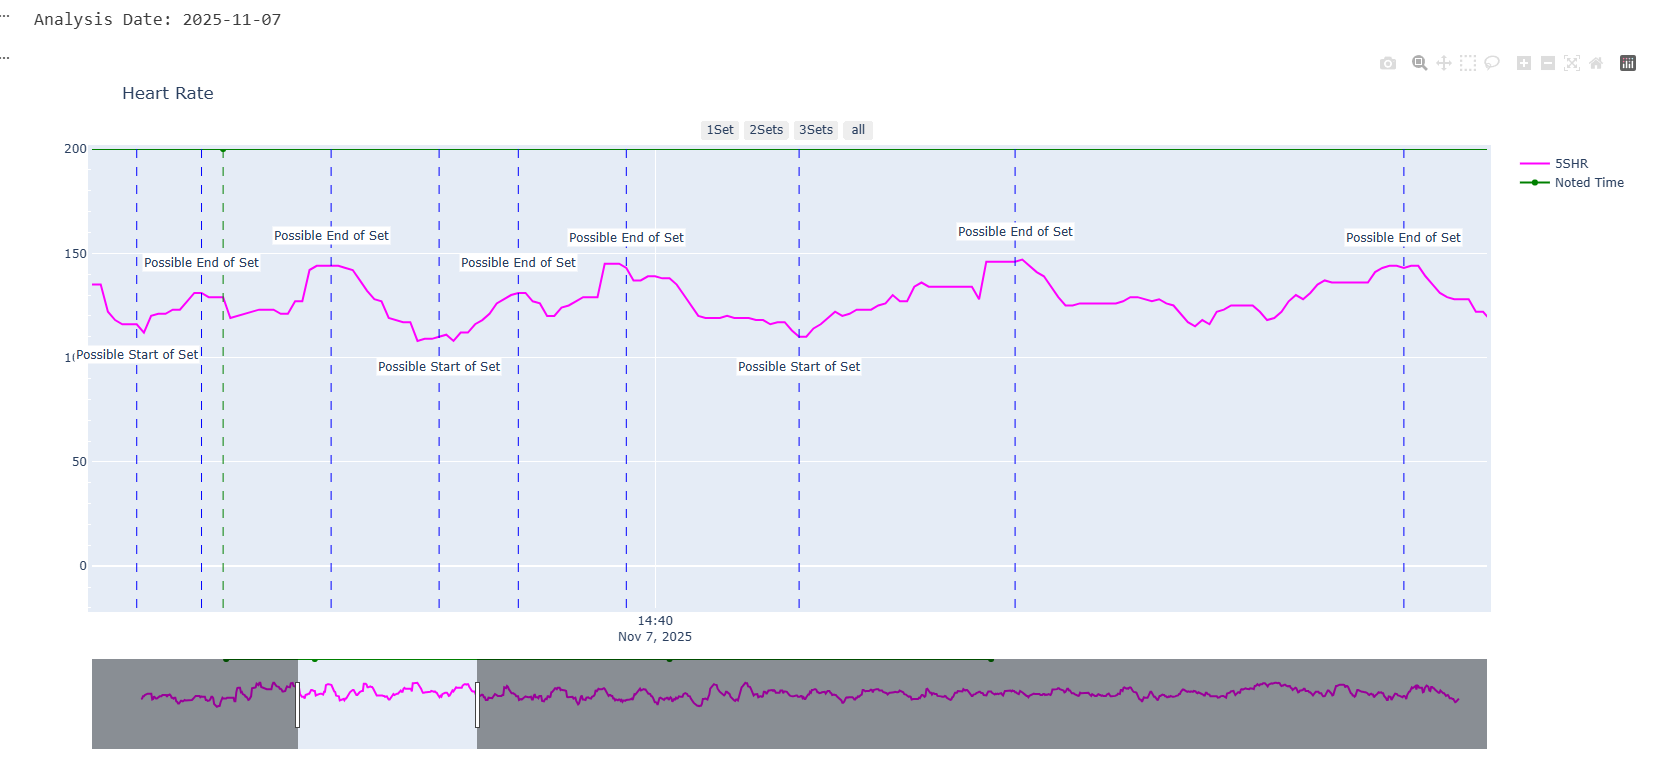

It turns out that using the out of the box Scipy stats Find Peak detection, although not perfect, is the best way, without Machine Learning, to split sets in to different sections.

In [21]:
# Please set the Plot Range within 1 week to avoid buffer overflows
StartPlotTime=datetime(2025, 11,21,9,0,0)
EndPlotTime=datetime(2025, 11,21,21,0,0)

# Derrive Masks for Plotting
maskTime = (main_df["DateTime"] >= StartPlotTime) & (main_df["DateTime"] <= EndPlotTime)
maskTime2 = (df_exercise["DateTime"] >= StartPlotTime) & (df_exercise["DateTime"] <= EndPlotTime)

mask = ((main_df["5SHR"].notna()) & maskTime)
mask2 = ((df_exercise["exercise"].notna()) & maskTime2)

DiffMask = (False)
ExerciseMask = (False)



In [23]:
# Plotly Interactive Graphic All in One Overview
fig2 = go.Figure(layout_yaxis_range=[-20,200], layout = dict(title='All in One Overview', xaxis=dict(type='date'),width=1600, height=800 ))

#maskTime = (main_df["DateTime"] >= StartPlotTime) & (main_df["DateTime"] <= EndPlotTime)


#All Data
for col in main_df:
    fig2.add_trace(go.Scatter(x=main_df[maskTime]["DateTime"], y=main_df[maskTime][col],mode="lines", name=col, connectgaps=True,stackgaps='infer zero'))

# Heart Rate Data
#fig2.add_trace(go.Scatter(x=main_df[maskTime]["DateTime"], y=main_df[maskTime]["5SHR"],mode="lines", name="5SHR", connectgaps=True,stackgaps='infer zero'))
#fig2.add_trace(go.Scatter(x=main_df[maskTime]["DateTime"], y=main_df[maskTime]["1MHR"],mode="lines", name="1MHR", connectgaps=True,stackgaps='infer zero'))

#Correlation Steps and Heart Rate (and their pct_change)
# fig2.add_trace(go.Scatter(x=main_df[maskTime]["DateTime"], y=main_df[maskTime]["1MHR"],mode="lines", name="1MHR", connectgaps=True,stackgaps='infer zero', line_color="blue"))
# fig2.add_trace(go.Bar(x=main_df[maskTime]["DateTime"].shift(1), y=main_df[maskTime]["Steps"],name="Steps",width=60000, marker_color='yellow', opacity=0.5))
# fig2.add_trace(go.Scatter(x=main_df[maskTime]["DateTime"].shift(-2), y=main_df[maskTime]["1MHR"].ffill().pct_change(periods=2).multiply(100),mode='lines', name="HR PCT_Change",connectgaps=False,stackgaps='infer zero', line_color="cyan"))
# fig2.add_trace(go.Scatter(x=main_df[maskTime]["DateTime"].shift(-2), y=main_df[maskTime]["Steps"].ffill().pct_change(periods=2).multiply(10),mode='lines', name="Steps PCT_Change",connectgaps=False,line_color="orange"))
#fig2.add_trace(go.Scatter(x=main_df[maskTime]["DateTime"], y=main_df[maskTime]["1MHR"].diff(),mode='lines', name="HR diff",connectgaps=False,stackgaps='infer zero', line_color="yellow"))


# Start and End Annotations of Training Sessions
for file in ADD_TCX:
    if ADD_TCX[file]["StartTime"] < StartPlotTime:
        continue
    if ADD_TCX[file]["EndTime"] > EndPlotTime:
        continue
    fig2.add_annotation(x=ADD_TCX[file]["StartTime"],y=200, text="Start", yshift=20,  showarrow=False)
    fig2.add_annotation(x=ADD_TCX[file]["EndTime"],y=0,text="End",  yshift=-20,  showarrow=False)
    fig2.add_vline(x=ADD_TCX[file]["StartTime"],  line_width=1, line_dash="dash", line_color="green")
    fig2.add_vline(x=ADD_TCX[file]["EndTime"], line_width=1, line_dash="dash", line_color="green")

# Axis and Layout Settings
fig2.update_yaxes( type="linear", range=(-20,200), autorange= False, constrain="domain")
fig2.update_xaxes(
    rangeslider_visible=True,
    rangeselector=dict(
        buttons=list([
            dict(count=900, label="15min", step="second", stepmode="backward"),
            dict(count=60, label="1h", step="minute", stepmode="backward"),
            dict(count=24, label="1d", step="hour", stepmode="todate"),
            dict(count=7, label="1week", step="day", stepmode="backward"),
            dict(step="all")
        ])
    ),
    rangeslider_yaxis_range=[0,200],rangeslider_yaxis_rangemode="fixed"
)
fig2.show()

In [32]:
# Plotly Interactive Graphic Multiple Days
# Please set the Plot Range within 1 week to avoid buffer overflows (above section)
fig3 = go.Figure(layout_yaxis_range=[-20,200], layout = dict(title='Multi Day Comparison', xaxis=dict(type='date'),width=1600, height=800 ))

# Heart Rate Data
fig3.add_trace(go.Scatter(x=main_df[(mask)]["DateTime"], y=main_df[mask]["5SHR"],mode="lines", name="5SHR",connectgaps=False,stackgaps='infer zero',line_color='magenta'))


# Start / End Annotations for Training Sessions
for file in ADD_TCX:
    if ADD_TCX[file]["StartTime"] < StartPlotTime:
        continue
    if ADD_TCX[file]["EndTime"] > EndPlotTime:
        continue
    fig3.add_annotation(x=ADD_TCX[file]["StartTime"],y=200, text="Start", yshift=20,  showarrow=False)
    fig3.add_annotation(x=ADD_TCX[file]["EndTime"],y=-20,text="End",  yshift=-20,  showarrow=False)
    fig3.add_vline(x=ADD_TCX[file]["StartTime"], line_width=1, line_dash="dash", line_color="black")
    fig3.add_vline(x=ADD_TCX[file]["EndTime"], line_width=1, line_dash="dash", line_color="black")

    DiffMask = DiffMask | ((main_df["DateTime"] >= ADD_TCX[file]["StartTime"]) & (main_df["DateTime"] <= ADD_TCX[file]["EndTime"]))
    ExerciseMask = ExerciseMask | ((df_exercise["DateTime"] >= ADD_TCX[file]["StartTime"]) & (df_exercise["DateTime"] <= ADD_TCX[file]["EndTime"]))


# Steps Data
#fig3.add_trace(go.Bar(x=main_df[DiffMask]["DateTime"], y=main_df[DiffMask]["Steps"],name="Steps",width=60000, marker_color='violet'))

# Exercise Annotations Noted Times
for idx in df_exercise[(ExerciseMask & (df_exercise.Time!="nan"))].index:
    # hovertext= df_exercise.at[idx,"weight_kg"]
    # hovertext+="kg * " 
    # hovertext+=df_exercise.at[idx,"repetitions" ]
    fig3.add_vline(x=df_exercise.at[idx,"DateTime"], line_width=1, line_dash="dash", line_color="green")
    #fig3.add_scatter(x=df_exercise.at[idx,"DateTime"],y=200, text=df_exercise.at[idx,"exercise"], hoverlabel=hovertext,  color="Orange")

# Exercise Annotations Interpolated Times
for idx in df_exercise[(ExerciseMask & (df_exercise.Time=="nan"))].index:
    # hovertext= df_exercise.at[idx,"weight_kg"]
    # hovertext+="kg * " 
    # hovertext+=df_exercise.at[idx,"repetitions" ]
    fig3.add_vline(x=df_exercise.at[idx,"DateTime"], line_width=1, line_dash="dash", line_color="red")
    #fig3.add_scatter(x=df_exercise.at[idx,"DateTime"],y=200, text=df_exercise.at[idx,"exercise"], hoverlabel=hovertext,  color="Orange")

# Exercise Start Points Interpolated Times
fig3.add_trace(go.Scatter(
    x=df_exercise[(ExerciseMask & (df_exercise.Time=="nan"))]["DateTime"],
    y=200*np.ones(df_exercise[(ExerciseMask & (df_exercise.Time=="nan"))].shape[0]),
    xperiodalignment="middle",
    marker=dict(size=1, symbol="diamond", line=dict(width=0)),
    fillcolor="red",
    # hovertemplate =
    # '<i>Price</i>: $%{y:.2f}'+
    # '<br><b>X</b>: %{x}<br>'+
    # '<b>%{text}</b>',
    text = ['Exercise:{} <br> Repetitions: {} <br> Weight: {} '.format(i,r,w) for i,r,w in df_exercise[(ExerciseMask & (df_exercise.Time=="nan"))][["exercise", "repetitions","weight_kg"]].values],
    name="Interpolated Time"
    ))

# Exercise Start Points Noted Times
fig3.add_trace(go.Scatter(
    x=df_exercise[(ExerciseMask & (df_exercise.Time!="nan"))]["DateTime"],
    y=200*np.ones(df_exercise[(ExerciseMask & (df_exercise.Time!="nan"))].shape[0]),
    xperiodalignment="middle",
    marker=dict(size=1, symbol="diamond", line=dict(width=0)),
    fillcolor="green",
    # hovertemplate =
    # '<i>Price</i>: $%{y:.2f}'+
    # '<br><b>X</b>: %{x}<br>'+
    # '<b>%{text}</b>',
    text = ['Exercise:{} <br> Repetitions: {} <br> Weight: {} '.format(i,r,w) for i,r,w in df_exercise[(ExerciseMask & (df_exercise.Time!="nan"))][["exercise", "repetitions","weight_kg"]].values],
    name="Noted Time"
    ))

# Unified Hovermode Infobox
fig3.update_layout(hovermode="x unified")

# Create diff of last two datapoints
fig3.add_trace(go.Scatter(x=main_df[DiffMask]["DateTime"].shift(-2), y=main_df[DiffMask]["5SHR"].ffill().pct_change(periods=4).multiply(100),mode='lines', name="HR PCT_Change",connectgaps=False,stackgaps='infer zero'))
fig3.add_trace(go.Scatter(x=main_df[DiffMask]["DateTime"], y=main_df[DiffMask]["5SHR"].diff(),mode='lines', name="HR diff",connectgaps=False,stackgaps='infer zero'))


for iloc in list(detections["ilocs"]):
    detected_time = main_df.dropna(subset=["5SHR"]).iloc[iloc]["DateTime"]
    #print("Change detected at: " + str(detected_time))
    if detected_time < StartPlotTime:
        continue
    if detected_time > EndPlotTime:
        continue
    fig3.add_vline(x=detected_time, line_width=1, line_dash="dash", line_color="blue")

# fig3.add_trace(go.Scatter(
#     x=main_df[["DateTime"]].dropna().iloc[list(detections["ilocs"])]["DateTime"],
#     y=200*np.ones(detections.shape[0]),
#     xperiodalignment="middle",
#     marker=dict(size=3, symbol="diamond", line=dict(width=0)),
#     line_color="blue",
#     name="Moving Window Detection"
#     ))


#figure = plt.gcf()
#figure.set_size_inches(15,7)

#set major ticks to 10min in 600000ms, minor ticks to 2 min ( 60* 5s =300s)
# Layout Settings
fig3.update_yaxes( type="linear", range=(-20,200), autorange= False, constrain="domain")
fig3.update_xaxes(
    rangeslider_visible=True,
    rangeselector=dict(
        buttons=list([
            dict(count=900, label="15min", step="second", stepmode="backward"),
            dict(count=60, label="1h", step="minute", stepmode="backward"),
            dict(count=24, label="1d", step="hour", stepmode="todate"),
            dict(count=7, label="1week", step="day", stepmode="backward"),
            dict(step="all")
        ])
    )
)

# Interactive Range Slider Settings
fig3.update_xaxes(rangeslider_yaxis_range=[0,200],rangeslider_yaxis_rangemode="fixed")
fig3.update_layout(
    autosize=True,
    margin=dict(
        l=50,
        r=50,
        b=100,
        t=100,
        pad=4
    )
    # ,
    # xaxis_tickformatstops = [
    #     dict(dtickrange=[None, 1000], value="%H:%M:%S.%L ms"),
    #     dict(dtickrange=[1000, 60000], value="%H:%M:%S s"),
    #     dict(dtickrange=[60000, 3600000], value="%H:%M m"),
    #     dict(dtickrange=[3600000, 86400000], value="%H:%M h"),
    #     dict(dtickrange=[86400000, 604800000], value="%e. %b d"),
    #     dict(dtickrange=[604800000, "M1"], value="%e. %b w"),
    #     dict(dtickrange=["M1", "M12"], value="%b '%y M"),
    #     dict(dtickrange=["M12", None], value="%Y Y")
    # ]
    )

fig3.show()

In [44]:
# Plotly Interactive Graphic Detailed HR + Exercise Annotations

#Chart Settings
showNotedTimes= True
showInterpolatedTimes= False
showSteps= False
showPctChange= False
showMovingWindowDetections = False
showPeaks = True

# Separate Graphic for each Day in Range
for AnalysisDate in pd.date_range(StartPlotTime.date(), EndPlotTime.date(), freq='D'):
    if AnalysisDate.weekday() < 5:
        print("Analysis Date: " + str(AnalysisDate.date()))
    else:
        print(f"{AnalysisDate} is a weekend.")
        continue
    


    AnalysisStart = pd.to_datetime(AnalysisDate.strftime("%Y.%m.%d") +" 09:00:00",format="%Y.%m.%d %H:%M:%S")
    AnalysisEnd = pd.to_datetime(AnalysisDate.strftime("%Y.%m.%d") +" 21:00:00",format="%Y.%m.%d %H:%M:%S")

    maskTime = (main_df["DateTime"] >= AnalysisStart) & (main_df["DateTime"] <= AnalysisEnd)
    maskTime2 = (df_exercise["DateTime"] >= AnalysisStart) & (df_exercise["DateTime"] <= AnalysisEnd)

    mask = ((main_df["5SHR"].notna()) & maskTime)
    mask2 = ((df_exercise["exercise"].notna()) & maskTime2)

    DiffMask = (False)
    ExerciseMask = (False)

    # Base Layout 
    fig3 = go.Figure(layout_yaxis_range=[-20,200], layout = dict(hovermode="x",
                                                                  hoverlabel=dict(
        bgcolor="white",
        font_size=16,
        font_family="Rockwell",
        align="right"
        ),hoverdistance=100,
         
          title='Heart Rate', xaxis=dict(type='date'),width=1600, height=800, autosize=True,
        margin=dict(
            l=50,
            r=50,
            b=100,
            t=100,
            pad=4
        ) ))

    # Heart Rate Data
    fig3.add_trace(go.Scatter(x=main_df[(mask)]["DateTime"], y=main_df[mask]["5SHR"],mode="lines", name="5SHR",connectgaps=False,stackgaps='infer zero',line_color='magenta'))


    # Start / End Annotations for Training Sessions
    for file in ADD_TCX:
        if ADD_TCX[file]["StartTime"] < AnalysisStart:
            continue
        if ADD_TCX[file]["EndTime"] > AnalysisEnd:
            continue
        fig3.add_annotation(x=ADD_TCX[file]["StartTime"],y=200, text="Start", yshift=20,  showarrow=False)
        fig3.add_annotation(x=ADD_TCX[file]["EndTime"],y=-20,text="End",  yshift=-20,  showarrow=False)
        fig3.add_vline(x=ADD_TCX[file]["StartTime"], line_width=1, line_dash="dash", line_color="black")
        fig3.add_vline(x=ADD_TCX[file]["EndTime"], line_width=1, line_dash="dash", line_color="black")

        DiffMask = DiffMask | ((main_df["DateTime"] >= ADD_TCX[file]["StartTime"]) & (main_df["DateTime"] <= ADD_TCX[file]["EndTime"]))
        ExerciseMask = ExerciseMask | ((df_exercise["DateTime"] >= ADD_TCX[file]["StartTime"]) & (df_exercise["DateTime"] <= ADD_TCX[file]["EndTime"]))


    # Steps Data
    if showSteps:
        fig3.add_trace(go.Bar(x=main_df[DiffMask]["DateTime"], y=main_df[DiffMask]["Steps"],name="Steps",width=60000, marker_color='violet'))


    # Exercise Annotations Noted Times
    if showNotedTimes:
        for idx in df_exercise[(ExerciseMask & (df_exercise.Time!="nan"))].index:
            # hovertext= df_exercise.at[idx,"weight_kg"]
            # hovertext+="kg * " 
            # hovertext+=df_exercise.at[idx,"repetitions" ]
            fig3.add_vline(x=df_exercise.at[idx,"DateTime"], line_width=1, line_dash="dash", line_color="green")
            #fig3.add_scatter(x=df_exercise.at[idx,"DateTime"],y=200, text=df_exercise.at[idx,"exercise"], hoverlabel=hovertext,  color="Orange")
        # Exercise Start Points Noted Times
        fig3.add_trace(go.Scatter(
            x=df_exercise[(ExerciseMask & (df_exercise.Time!="nan"))]["DateTime"],
            y=200*np.ones(df_exercise[(ExerciseMask & (df_exercise.Time!="nan"))].shape[0]),
            xperiodalignment="middle",
            #marker=dict(size=1, symbol="diamond", line=dict(width=0)),
            fillcolor="green",
            line_color="green",connectgaps=False,
            # hovertemplate =
            # '<i>Price</i>: $%{y:.2f}'+
            # '<br><b>X</b>: %{x}<br>'+
            # '<b>%{text}</b>',
            text = ['Exercise:{} <br> Repetitions: {} <br> Weight: {} '.format(i,r,w) for i,r,w in df_exercise[(ExerciseMask & (df_exercise.Time!="nan"))][["exercise", "repetitions","weight_kg"]].values]
            ,name="Noted Time"
            ))
        

    
    if showInterpolatedTimes:
        # Exercise Annotations Interpolated Times
        for idx in df_exercise[(ExerciseMask & (df_exercise.Time=="nan"))].index:
            # hovertext= df_exercise.at[idx,"weight_kg"]
            # hovertext+="kg * " 
            # hovertext+=df_exercise.at[idx,"repetitions" ]
            fig3.add_vline(x=df_exercise.at[idx,"DateTime"], line_width=1, line_dash="dash", line_color="red")
            #fig3.add_annotation(x=df_exercise.at[idx,"DateTime"],y=200, text=df_exercise.at[idx,"DateTime"].strftime("%H:%m:%S"),bgcolor="white", arrowcolor="red", yshift=-20,  showarrow=False)
            #fig3.add_scatter(x=df_exercise.at[idx,"DateTime"],y=200, text=df_exercise.at[idx,"exercise"], hoverlabel=hovertext,  color="Orange")

        # Exercise Start Points Interpolated Times
        fig3.add_trace(go.Scatter(
            x=df_exercise[(ExerciseMask & (df_exercise.Time=="nan"))]["DateTime"],
            y=-20*np.ones(df_exercise[(ExerciseMask & (df_exercise.Time=="nan"))].shape[0]),
            xperiodalignment="middle",
            #marker=dict(size=1, symbol="diamond", line=dict(width=0)),
            fillcolor="red",
            line_color="red",connectgaps=False,
            #text=df_exercise[(ExerciseMask & (df_exercise.Time=="nan"))]["DateTime"],
            # hovertemplate =
            # '<i>Price</i>: $%{y:.2f}'+
            # '<br><b>X</b>: %{x}<br>'+
            # '<b>%{text}</b>',
            text = ['Exercise:{} <br> Repetitions: {} <br> Weight: {} '.format(i,r,w) for i,r,w in df_exercise[(ExerciseMask & (df_exercise.Time=="nan"))][["exercise", "repetitions","weight_kg"]].values]
            ,name="Interpolated Time"
            ))

    # Create diff of last two datapoints
    if showPctChange:
        fig3.add_trace(go.Scatter(x=main_df[DiffMask]["DateTime"].shift(-2), y=main_df[DiffMask]["5SHR"].ffill().pct_change(periods=4).multiply(100),mode='lines', name="HR PCT_Change",connectgaps=True,stackgaps='infer zero'))
        #fig3.add_trace(go.Scatter(x=main_df[DiffMask]["DateTime"], y=main_df[DiffMask]["5SHR"].diff(),mode='lines', name="HR diff",connectgaps=True,stackgaps='infer zero'))

    if showMovingWindowDetections:
        # Moving Window Detections for the Day
        for iloc in list(detections["ilocs"]):
            detected_time = main_df.dropna(subset="5SHR").iloc[iloc]["DateTime"]
            #print("Change detected at: " + str(detected_time))
            if detected_time.date() == AnalysisDate.date():
                #print("Change detected at: " + str(detected_time.date()) + " on " + str(AnalysisDate))
                fig3.add_vline(x=detected_time, line_width=1, line_dash="dash", line_color="blue")

        fig3.add_trace(go.Scatter(
            x=main_df[["DateTime"]].dropna().iloc[list(detections["ilocs"])]["DateTime"].where(lambda x: x.dt.date == AnalysisDate.date()).dropna(),
            y=0*np.ones(detections.shape[0]),
            xperiodalignment="middle",
            #mode="line",
            #marker=dict(size=3, symbol="diamond", line=dict(width=0)),
            line_color="blue",
            name="Moving Window Detection",connectgaps=False,visible="legendonly"
            
            ))
        fig3.add_shape(
            type="line",
            x0="2025-11-07 14:35:55",
            x1="2025-11-07 14:36:55",
            y0=138, y1=138, line=dict(
            color="blue",
            width=3))
        fig3.add_shape(
            type="line",
            x0="2025-11-07 14:36:55",
            x1="2025-11-07 14:38:05",
            y0=112, y1=112, line=dict(
            color="blue",
            width=3))
        
    # Auto Peak Detections for the Day
    if showPeaks:
        for iloc in list(peaks):
            detected_time = main_df.dropna(subset="5SHR").iloc[iloc]["DateTime"]
            #print("Change detected at: " + str(detected_time))
            if detected_time.date() == AnalysisDate.date():
                #print("Change detected at: " + str(detected_time.date()) + " on " + str(AnalysisDate))
                fig3.add_vline(x=detected_time, line_width=1, line_dash="dash", line_color="blue")
                fig3.add_annotation(x=detected_time,y=main_df.dropna(subset="5SHR").iloc[iloc]["5SHR"], text="Possible End of Set", bgcolor="white", arrowcolor="blue", yshift=+30,  showarrow=False)

        for iloc in list(peaks_v):
            detected_time = main_df.dropna(subset="5SHR").iloc[iloc]["DateTime"]
            #print("Change detected at: " + str(detected_time))
            if detected_time.date() == AnalysisDate.date():
                #print("Change detected at: " + str(detected_time.date()) + " on " + str(AnalysisDate))
                fig3.add_vline(x=detected_time, line_width=1, line_dash="dash", line_color="blue")
                fig3.add_annotation(x=detected_time,y=main_df.dropna(subset="5SHR").iloc[iloc]["5SHR"], text="Possible Start of Set", bgcolor="white", arrowcolor="blue", yshift=-30,  showarrow=False)



    # Layout Settings
    fig3.update_yaxes( type="linear", range=(-20,200), autorange= False, constrain="domain", minor_ticks="inside",minor=dict( tickcolor="white",tickmode='auto', showgrid=False))

    #Interactive Slider, set major ticks to 10min in 600000ms, minor ticks to 2 min ( 60* 5s =300s)
    fig3.update_xaxes(dtick=600000, #minor_ticks="inside",minor=dict(ticklen=60, tickcolor="black", gridcolor="white", tickmode='auto', nticks=5, showgrid=True),
        rangeslider_visible=True, rangeslider_yaxis_range=[0,200],rangeslider_yaxis_rangemode="fixed",
        rangeselector=dict( xanchor="center" , x=0.5,
                buttons=list([
                dict(count=600, label="1 Exercise", step="second", stepmode="backward"),
                dict(count=1200, label="2 Exercises", step="second", stepmode="backward"),
                dict(count=30, label="3 Exercises", step="minute", stepmode="todate"),
                dict(step="all")
            ])
        )
    )
    fig3.show()

Analysis Date: 2025-11-21


# Data storage (optional)

Here are some possible storage forms you could use for your project:
- releational database, e.g. using  https://docs.python.org/3/library/sqlite3.html
- pickle files https://docs.python.org/3/library/pickle.html
- iot data platforms, e.g. https://thingspeak.com/
- etc.



In [32]:
#extract data for next module
sdir= os.path.join(DATA_DIRECTORY, "Output")
main_df.to_pickle(os.path.join(sdir,"timeseries_data.pkl"))
df_exercise.to_pickle(os.path.join(sdir,"exercise_data.pkl"))
pd.DataFrame(ADD_TCX).to_pickle(os.path.join(sdir,"training_data.pkl"))
detections.to_pickle(os.path.join(sdir,"moving_window_detections.pkl"))
pd.DataFrame(peaks).to_pickle(os.path.join(sdir,"peaks.pkl"))
pd.DataFrame(peaks_v).to_pickle(os.path.join(sdir,"valleys.pkl"))

```{bibliography}
```

```{bibliography}
```

# References